## Get data from Zenodo

In [1]:
import subprocess
import os

output_dir = './data/'
os.makedirs('./data/', exist_ok=True)

cmd1 = ["wget", "-c", "-P", output_dir, "https://zenodo.org/records/17143346/files/PE_O5Like_snr20.h5"] # PE file
cmd2 = ["wget", "-c", "-P", output_dir, "https://zenodo.org/records/17143346/files/injections_Ninj_2e7_O5Like_snr20.h5"] # inj file
cmd3 = ["wget", "-c", "-P", output_dir, "https://zenodo.org/records/17143346/files/parent_galaxy_catalog_1.6M_dVdz.h5"] # parent galaxy sample
cmd4 = ["wget", "-c", "-P", output_dir, "https://zenodo.org/records/17143346/files/PE_O5Like_snr20_pixelated_nsidelist512-256-128-64-32-16-8_meanpixels15_skyconf0.9_nestFalse.h5"] # pixelated pe
subprocess.run(cmd1, capture_output=True, text=True)
subprocess.run(cmd2, capture_output=True, text=True)
subprocess.run(cmd3, capture_output=True, text=True)
subprocess.run(cmd4, capture_output=True, text=True)

CompletedProcess(args=['wget', '-c', '-P', './data/', 'https://zenodo.org/records/17143346/files/PE_O5Like_snr20_pixelated_nsidelist512-256-128-64-32-16-8_meanpixels15_skyconf0.9_nestFalse.h5'], returncode=0, stdout='', stderr='--2026-06-08 14:49:54--  https://zenodo.org/records/17143346/files/PE_O5Like_snr20_pixelated_nsidelist512-256-128-64-32-16-8_meanpixels15_skyconf0.9_nestFalse.h5\nResolving zenodo.org (zenodo.org)... 188.184.98.114, 137.138.153.219, 188.185.48.75, ...\nConnecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.\nHTTP request sent, awaiting response... 416 REQUESTED_RANGE_NOT_SATISFIABLE\n\n    The file is already fully retrieved; nothing to do.\n\n')

## Load data and pixelate catalogue (or load one already pixelated)

In [2]:
import os, sys
os.environ["CHIMERA_ENABLE_GPU"] = "False"
sys.path.append(os.getcwd()+'/../')
from CHIMERA import data as data
import h5py

fpe = "./data/PE_O5Like_snr20.h5"
gw_pe_det = data.load_gw_pe_samples(fpe, parameters=['m1det', 'm2det', 'dL', 'ra', 'dec', 'phi', 'theta'])
gw_pe_det = gw_pe_det.update(pe_prior=gw_pe_det.dL**2)

# You can skip the following line if you already have the pixelated PE
"""
nside_list = [512, 256, 128, 64, 32, 16, 8]
mean_npixels_event = 15
prefix = "./data/PE_O5Like_snr20"
nest = False
sky_conf = 0.9
gw_pe_det_pixelated = data.pixelize_gw_catalog(gw_pe_det,
                       nside_list,
                       mean_npixels_event,
                       sky_conf,
                       nest,
                       prefix,
                       ret_datastruct=True)
"""
# Reload pixelated PE
f_gw_pix = './data/PE_O5Like_snr20_pixelated_nsidelist512-256-128-64-32-16-8_meanpixels15_skyconf0.9_nestFalse.h5'
gw_pe_det_pixelated = data.load_pixelated_gw_catalog(f_gw_pix)

2026-06-08 14:49:56,799 - CHIMERA - INFO - Loading `CHIMERA`. GPU acceleration: False


## Instantiate population objects

In [3]:
from CHIMERA.cosmo import flrw
from CHIMERA.mass.conditioned import plp
from CHIMERA.rate import madau_dickinson
from CHIMERA.catalog import dVdz_completeness, pixelated_catalog, precompute_p_cat, save_p_cat, load_p_cat
from CHIMERA import population, compute_z_grids

fname_data_gal = "./data/parent_galaxy_catalog_1.6M_dVdz.h5"

cosmo = flrw(H0 = 70., Om0=0.25, z_max = 5.)
completeness = dVdz_completeness(z_range= [0.073, 1.3]) 
"""
z_grids = compute_z_grids(cosmo, 
                          gw_pe_det_pixelated, 
                          cosmo_prior = {'H0':[20,200]}, 
                          z_int_res = 500,)
p_cat, N_gal, P_compl = precompute_p_cat(
    completeness, 
    cosmo, 
    z_grids,
    fname_data_gal, 
    gw_pe_det_pixelated,
    z_err=0.001,
)
save_p_cat("./data/pcat_complete.h5", p_cat, N_gal, P_compl, z_grids)
"""
p_cat, N_gal, P_compl, z_grids = load_p_cat("./data/pcat_complete.h5")

gal_cat = pixelated_catalog(completeness, p_cat, N_gal, P_compl, z_grids)

mass = plp(m_low=5.1, m_high=87, lambda_peak=0.039, alpha=3.4, beta=1.1, delta_m=4.8, mu_g=34., sigma_g=3.6)
rate = madau_dickinson(gamma = 2.7, kappa =  3., zp = 2.)

population = population(cosmo, mass, rate, gal_cat=gal_cat, scale_free=True)

2026-06-08 14:49:58,696 - CHIMERA - INFO - Loading p_cat from './data/pcat_complete.h5'


## Plot pixelization scheme

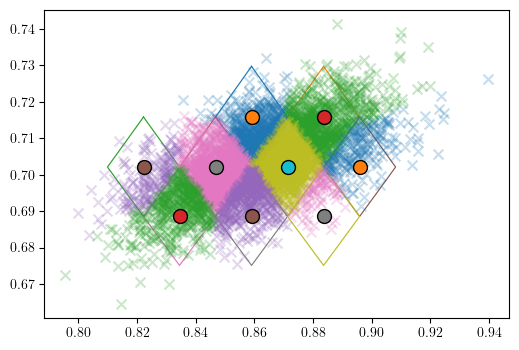

In [4]:
from CHIMERA.utils.plotting import plot_pixelization
import matplotlib.pyplot as plt

plot_pixelization(gw_pe_det_pixelated, 5)

## Instantiate selection function

In [5]:
from CHIMERA import selection_function

file_inj = "./data/injections_Ninj_2e7_O5Like_snr20.h5"
gw_inj_data = data.load_injection_data(file_inj, snr_cut=20, return_struct = True)

sel_fcn = selection_function(gw_inj_data, N_inj=20*1e6)

## Instantiate the hyperlikelihood 

In [6]:
from CHIMERA import hyperlikelihood

hyperlike = hyperlikelihood(  
    # data
    gw_pe_det_pixelated,
    # pop model
    population=population,
    # selection function
    selection_function=sel_fcn,
    # numerical stability
    pe_neff = 2.0,
    inj_neff = None, # default to 5*Nev  
    # KDE settings
    kind_kde = 'many-1d-binned',
    kernel='epan', # 'epan'
    kde_bw=None,
    cut_grid=2,
    num_bins=200,
)

2026-06-08 14:50:03,280 - CHIMERA - WARNING - `kde_bw` is None, using Scott rule for bandwidth.
2026-06-08 14:50:03,346 - CHIMERA - INFO - Created hyperlikelihood model. Using 300 GW events.


## 1d over H0

50it [02:28,  2.96s/it]
/tmp/ipykernel_12004/4280466871.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norms_evs = np.trapz(like_evs_H0, x=H0, axis=0)
/tmp/ipykernel_12004/4280466871.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  like_H0 /= np.trapz(like_H0, H0)


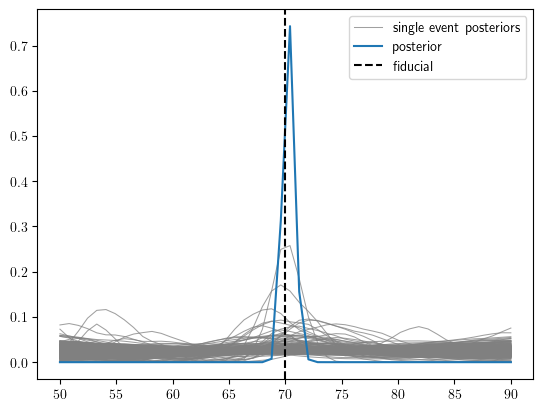

In [7]:
import numpy as np
import tqdm
import matplotlib.pyplot as plt

H0 = np.linspace(50, 90, 50)
log_like_evs_H0 = np.zeros((H0.shape[0], hyperlike.nevents))
loglike_H0 = np.zeros_like(H0)
N_exp_H0 = np.zeros_like(H0)

for i, h0 in tqdm.tqdm(enumerate(H0)):
  log_like_evs, N_exp, neff_inj, log_hyperlike = hyperlike.compute_all(H0=h0)
  log_like_evs_H0[i] = log_like_evs
  N_exp_H0[i] = N_exp
  loglike_H0[i] = log_hyperlike

# exponentiate and normalize
log_like_evs_H0 -= np.nanmax(log_like_evs_H0)
like_evs_H0 = np.exp(log_like_evs_H0) 
norms_evs = np.trapz(like_evs_H0, x=H0, axis=0)

loglike_H0 -= np.nanmax(loglike_H0)
like_H0 = np.exp(loglike_H0)
like_H0 /= np.trapz(like_H0, H0)

for e in range(hyperlike.nevents):
    lab = 'single event posteriors' if e == 0 else None
    plt.plot(H0, like_evs_H0[:,e]/norms_evs[e], c='gray', lw=0.75, alpha=0.75, label = lab )
plt.plot(H0, like_H0, label='posterior')
plt.axvline(70, ls='--', c='k', label= 'fiducial')
plt.legend()
plt.show()